# Sign Language MNIST — PyTorch: Entrenamiento, Guardado y Exportación de Modelos

Este cuadernillo entrena una **Red Neuronal Multicapa (MLP)** sobre el dataset **Sign Language MNIST**, aplicando la metodología de guardado y exportación de modelos presentada en el cuadernillo `04_pytorch_save.ipynb`.

## Contenido
1. Configuración del entorno
2. Carga y preparación del dataset
3. Visualización de ejemplos de entrenamiento
4. Arquitectura MLP y bucle de entrenamiento con checkpointing
5. Gráficas de Loss y Accuracy
6. Persistencia del modelo: carga del mejor checkpoint
7. Exportación con TorchScript
8. Evaluación: Matriz de Confusión y predicciones visuales

---
## 1.  Configuración del Entorno

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

# ── Semilla de reproducibilidad ──────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Dispositivo ──────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo activo: {device}")

Dispositivo activo: cpu


---
## 2.  Carga y Preparación del Dataset

### 2.1 Mapeo de Etiquetas

El dataset Sign Language MNIST contiene 24 clases (letras A–Y), **omitiendo J (índice 9) y Z (índice 25)** porque requieren movimiento y no son representables como imágenes estáticas.

In [14]:
# Diccionario: índice numérico → letra del alfabeto ASL
# Se omiten J=9 y Z=25 (requieren movimiento)
LABEL_MAP = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E',
    5: 'F', 6: 'G', 7: 'H', 8: 'I',
    # 9: 'J'  ← omitida
    10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O',
    15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T',
    20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y',
    # 25: 'Z'  ← omitida
}

NUM_CLASSES = len(LABEL_MAP)   # 24 clases
print(f"Número de clases: {NUM_CLASSES}")
print(f"Clases: {list(LABEL_MAP.values())}")

Número de clases: 24
Clases: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Mapeo de etiquetas original a contigua: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 23: 22, 24: 23}


### 2.2 Carga y División 80/20

In [15]:
# ── Ajusta esta ruta al directorio donde tengas el CSV ───────────────────────
CSV_PATH = "/content/sign_mnist_train.csv"

df = pd.read_csv(CSV_PATH)
print(f"Shape del dataset completo: {df.shape}")
print(f"\nDistribución de clases:")
print(df['label'].value_counts().sort_index())
df.head(3)

Shape del dataset completo: (27455, 785)

Distribución de clases:
label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195


In [16]:
from sklearn.model_selection import train_test_split

# Separar features y etiquetas
X = df.drop(columns=['label']).values.astype(np.float32)   # (N, 784)
y = df['label'].values.astype(np.int64)                     # (N,)

# Normalización al rango [0, 1]
X = X / 255.0

# División estratificada 80 % entrenamiento / 20 % validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Entrenamiento : {X_train.shape[0]:>6} muestras")
print(f"Validación    : {X_val.shape[0]:>6} muestras")
print(f"\nRango de valores X_train: [{X_train.min():.3f}, {X_train.max():.3f}]")

Entrenamiento :  21964 muestras
Validación    :   5491 muestras

Rango de valores X_train: [0.000, 1.000]
Rango de valores y_train: [0, 23]
Rango de valores y_val:   [0, 23]


### 2.3 Dataset y DataLoader personalizados

In [17]:
class SignLanguageDataset(Dataset):
    """Dataset de Sign Language MNIST ya normalizado."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)   # (N, 784)
        self.y = torch.tensor(y, dtype=torch.long)       # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 256

train_dataset = SignLanguageDataset(X_train, y_train)
val_dataset   = SignLanguageDataset(X_val,   y_val)

dataloader = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True),
    'val'  : DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True),
}

print(f"Batches de entrenamiento : {len(dataloader['train'])}")
print(f"Batches de validación    : {len(dataloader['val'])}")

Batches de entrenamiento : 86
Batches de validación    : 22


---
## 3.  Visualización de Ejemplos de Entrenamiento

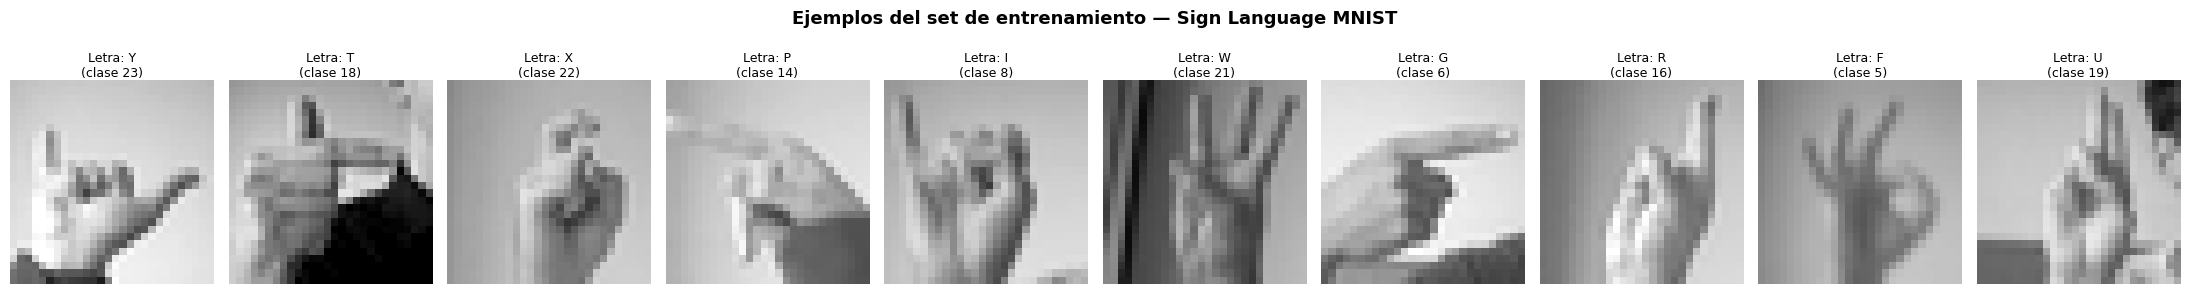

Figura guardada como 'train_samples.png'


In [18]:
def visualize_samples(X: np.ndarray, y: np.ndarray,
                      label_map: dict, n: int = 10,
                      random_state: int = 42) -> None:
    """
    Toma `n` ejemplos del conjunto, los redimensiona de (784,) → (28, 28)
    y los muestra con su letra del alfabeto ASL.
    """
    rng = np.random.RandomState(random_state)
    indices = rng.choice(len(X), size=n, replace=False)

    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 3))
    fig.suptitle('Ejemplos del set de entrenamiento — Sign Language MNIST',
                 fontsize=13, fontweight='bold', y=1.02)

    for ax, idx in zip(axes, indices):
        img = X[idx].reshape(28, 28)          # vector 784 → matriz 28×28
        label_idx = y[idx]
        letra = label_map.get(label_idx, '?')

        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"Letra: {letra}\n(clase {label_idx})",
                     fontsize=9, pad=3)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('train_samples.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Figura guardada como 'train_samples.png'")


visualize_samples(X_train, y_train, LABEL_MAP, n=10)

---
## 4.  Arquitectura MLP

Diseñamos una red **Multicapa Perceptrón** con:
- Capas **Linear** para transformaciones afines.
- **BatchNorm1d** para estabilizar el entrenamiento y acelerar la convergencia.
- **ReLU** como función de activación no lineal.
- **Dropout** para regularización y reducción del sobreajuste.

In [19]:
class SignLanguageMLP(nn.Module):
    """Red Neuronal Multicapa para clasificación ASL (24 clases)."""

    def __init__(self, input_dim: int = 784, num_classes: int = 24,
                 hidden_dims: list = None, dropout: float = 0.3):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [512, 256, 128]

        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(p=dropout),
            ]
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = SignLanguageMLP(input_dim=784, num_classes=NUM_CLASSES,
                        hidden_dims=[512, 256, 128], dropout=0.3)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")

SignLanguageMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=24, bias=True)
  )
)

Parámetros entrenables: 571,032


---
## 5. Bucle de Entrenamiento con Checkpoint del Mejor Modelo

### 📌 ¿Por qué guardar solo el `state_dict`?

> Guardar el **`state_dict`** (y no el modelo completo con `torch.save(model, ...)`) es la práctica recomendada por PyTorch por tres razones fundamentales:
>
> 1. **Eficiencia**: Solo se guardan los tensores de pesos, no el grafo computacional completo.
> 2. **Flexibilidad**: Puedes modificar la clase del modelo (añadir capas de análisis, cambiar nombres internos) y aun así cargar los pesos, siempre que la arquitectura sea compatible.
> 3. **Portabilidad**: El archivo `.pt` puede cargarse en cualquier máquina que tenga PyTorch instalado, sin importar cómo se importó originalmente el módulo.
>
> Si guardas el modelo entero (`torch.save(model, ...)`), Python serializa la referencia a la clase. Esto significa que el archivo **solo funciona si la clase está definida de la misma manera y en la misma ruta de importación** — mucho menos flexible.

En el bucle a continuación, **guardamos el checkpoint solo cuando la `val_acc` mejora**, replicando exactamente el patrón del cuadernillo `04_pytorch_save.ipynb`.

In [20]:
def fit(model: nn.Module,
        dataloader: dict,
        epochs: int = 30,
        lr: float = 1e-3,
        checkpoint_path: str = './checkpoint.pt') -> dict:
    """
    Entrena el modelo y guarda el state_dict cuando mejora la val_acc.

    Returns
    -------
    history : dict con listas de train_loss, val_loss, train_acc, val_acc
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [],  'val_acc': []}

    for epoch in range(1, epochs + 1):

        # ── Fase de entrenamiento ────────────────────────────────────────────
        model.train()
        train_loss, train_acc = [], []
        bar = tqdm(dataloader['train'], desc=f"Epoch {epoch:>2}/{epochs} [Train]",
                   leave=False)
        for X_batch, y_batch in bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_hat = model(X_batch)
            loss = criterion(y_hat, y_batch)
            loss.backward()
            optimizer.step()

            train_loss.append(loss.item())
            acc = (y_batch == torch.argmax(y_hat, dim=1)).float().mean().item()
            train_acc.append(acc)
            bar.set_postfix(loss=f"{np.mean(train_loss):.4f}",
                            acc=f"{np.mean(train_acc):.4f}")

        # ── Fase de validación ───────────────────────────────────────────────
        model.eval()
        val_loss, val_acc = [], []
        with torch.no_grad():
            bar = tqdm(dataloader['val'], desc=f"Epoch {epoch:>2}/{epochs} [Val] ",
                       leave=False)
            for X_batch, y_batch in bar:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_hat = model(X_batch)
                loss = criterion(y_hat, y_batch)
                val_loss.append(loss.item())
                acc = (y_batch == torch.argmax(y_hat, dim=1)).float().mean().item()
                val_acc.append(acc)
                bar.set_postfix(val_loss=f"{np.mean(val_loss):.4f}",
                                val_acc=f"{np.mean(val_acc):.4f}")

        scheduler.step()

        # ── Métricas de la época ─────────────────────────────────────────────
        e_train_loss = np.mean(train_loss)
        e_val_loss   = np.mean(val_loss)
        e_train_acc  = np.mean(train_acc)
        e_val_acc    = np.mean(val_acc)

        history['train_loss'].append(e_train_loss)
        history['val_loss'].append(e_val_loss)
        history['train_acc'].append(e_train_acc)
        history['val_acc'].append(e_val_acc)

        # ── Checkpoint: guardar SOLO si mejora la val_acc ────────────────────
        checkpoint_flag = ""
        if e_val_acc > best_val_acc:
            best_val_acc = e_val_acc
            torch.save(model.state_dict(), checkpoint_path)
            checkpoint_flag = f"  ✅ Checkpoint guardado (val_acc={best_val_acc:.4f})"

        print(f"Epoch {epoch:>2}/{epochs}  "
              f"loss={e_train_loss:.4f}  val_loss={e_val_loss:.4f}  "
              f"acc={e_train_acc:.4f}  val_acc={e_val_acc:.4f}"
              f"{checkpoint_flag}")

    print(f"\n🏆 Mejor val_acc alcanzada: {best_val_acc:.4f}")
    return history

In [21]:
CHECKPOINT_PATH = './checkpoint.pt'
EPOCHS = 30

history = fit(model, dataloader,
              epochs=EPOCHS,
              lr=1e-3,
              checkpoint_path=CHECKPOINT_PATH)

Epoch  1/30 [Train]:   0%|          | 0/86 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch  1/30 [Val] :   0%|          | 0/22 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  1/30  loss=1.6595  val_loss=1.2072  acc=0.5876  val_acc=0.7585  ✅ Checkpoint guardado (val_acc=0.7585)


Epoch  2/30  loss=0.4127  val_loss=0.9241  acc=0.9233  val_acc=0.7673  ✅ Checkpoint guardado (val_acc=0.7673)


Epoch  3/30  loss=0.1396  val_loss=0.7534  acc=0.9787  val_acc=0.7999  ✅ Checkpoint guardado (val_acc=0.7999)


Epoch  4/30  loss=0.0882  val_loss=0.8697  acc=0.9848  val_acc=0.7229


...

Epoch 26/30  loss=0.0020  val_loss=0.0001  acc=1.0000  val_acc=1.0000


Epoch 27/30  loss=0.0025  val_loss=0.0001  acc=0.9998  val_acc=1.0000


Epoch 28/30  loss=0.0023  val_loss=0.0001  acc=0.9998  val_acc=1.0000


Epoch 29/30  loss=0.0022  val_loss=0.0000  acc=1.0000  val_acc=1.0000


Epoch 30/30  loss=0.0020  val_loss=0.0000  acc=1.0000  val_acc=1.0000

🏆 Mejor val_acc alcanzada: 1.0000


---
## 6.  Gráficas de Loss y Accuracy

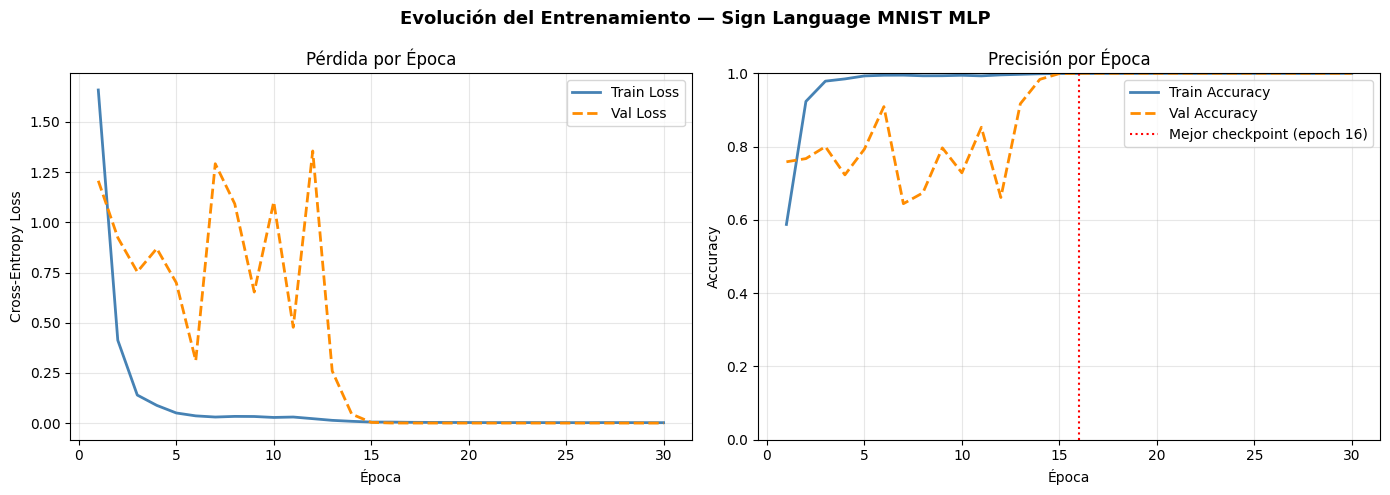

Mejor val_acc = 1.0000 en época 16
Figura guardada como 'training_curves.png'


In [22]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolución del Entrenamiento — Sign Language MNIST MLP',
             fontsize=13, fontweight='bold')

# ── Pérdida ──────────────────────────────────────────────────────────────────
ax1.plot(epochs_range, history['train_loss'], label='Train Loss',
         color='steelblue', linewidth=2)
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',
         color='darkorange', linewidth=2, linestyle='--')
ax1.set_xlabel('Época')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Pérdida por Época')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Precisión ────────────────────────────────────────────────────────────────
ax2.plot(epochs_range, history['train_acc'], label='Train Accuracy',
         color='steelblue', linewidth=2)
ax2.plot(epochs_range, history['val_acc'],   label='Val Accuracy',
         color='darkorange', linewidth=2, linestyle='--')
best_epoch = int(np.argmax(history['val_acc'])) + 1
best_acc   = max(history['val_acc'])
ax2.axvline(best_epoch, color='red', linestyle=':', linewidth=1.5,
            label=f'Mejor checkpoint (epoch {best_epoch})')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_title('Precisión por Época')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Mejor val_acc = {best_acc:.4f} en época {best_epoch}")
print("Figura guardada como 'training_curves.png'")

---
## 7.  Persistencia del Modelo: Carga del Mejor Checkpoint

###  ¿Por qué es fundamental guardar solo el `state_dict`?

> **Guardar solo el `state_dict`** separa los **pesos** (datos) de la **arquitectura** (código). Esto proporciona:
>
> - **Independencia de la serialización de Python**: `torch.save(model, ...)` usa `pickle`, que serializa la *referencia* a la clase. Si mueves el código a otro proyecto o refactorizas la clase, el archivo `.pt` dejará de funcionar. Con el `state_dict`, solo necesitas que la arquitectura sea compatible.
> - **Guardado selectivo en checkpoints**: Puedes guardar solo los pesos cuando hay mejora real, ahorrando disco y tiempo. También puedes incluir en un único `.pt` el estado del optimizador, la época, las métricas, etc.
> - **Compatibilidad con exportación**: TorchScript, ONNX y otros formatos de producción trabajan con la arquitectura viva del modelo; el `state_dict` es el puente natural para restaurarla antes de exportar.

In [23]:
# ── Cargar los pesos del mejor modelo guardado ───────────────────────────────
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()
print(f"✅ Mejor modelo cargado desde '{CHECKPOINT_PATH}'")

# Verificación rápida de la precisión con el modelo restaurado
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    model.to(device)
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = torch.argmax(model(X_batch), dim=1)
            correct += (preds == y_batch).sum().item()
            total   += len(y_batch)
    return correct / total

val_acc = evaluate(model, dataloader['val'])
print(f"Precisión en validación (mejor checkpoint): {val_acc:.4f} ({val_acc*100:.2f}%)")

✅ Mejor modelo cargado desde './checkpoint.pt'
Precisión en validación (mejor checkpoint): 1.0000 (100.00%)


---
## 8.  Exportación Avanzada con TorchScript

TorchScript genera una **representación intermedia** del modelo que puede ejecutarse **sin Python** (por ejemplo, en C++, Android, iOS). Existen dos métodos:

| Método | Descripción | Cuándo usarlo |
|---|---|---|
| **Tracing** | Graba las operaciones con un ejemplo de entrada | Modelos sin control de flujo condicional |
| **Scripting** | Analiza el código Python directamente | Modelos con `if/else` o bucles dependientes de los datos |

Incluimos un módulo de **preprocesado** en el modelo exportado para que en producción no sea necesario normalizar manualmente los datos.

In [24]:
class SignPreprocessing(nn.Module):
    """Normaliza píxeles de [0, 255] a [0, 1] dentro del modelo."""
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x / 255.0


class SignPostprocessing(nn.Module):
    """Devuelve probabilidades y clase predicha."""
    def __init__(self):
        super().__init__()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x: torch.Tensor):
        return self.softmax(x), torch.argmax(x, dim=1)


# Modelo de producción: preprocesado + MLP + postprocesado
production_model = nn.Sequential(
    SignPreprocessing(),
    model.cpu(),
    SignPostprocessing()
)
production_model.eval()
print(production_model)

Sequential(
  (0): SignPreprocessing()
  (1): SignLanguageMLP(
    (net): Sequential(
      (0): Linear(in_features=784, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Dropout(p=0.3, inplace=False)
      (8): Linear(in_features=256, out_features=128, bias=True)
      (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): Dropout(p=0.3, inplace=False)
      (12): Linear(in_features=128, out_features=24, bias=True)
    )
  )
  (2): SignPostprocessing(
    (softmax): Softmax(dim=1)
  )
)


In [25]:
# ── TRACING ──────────────────────────────────────────────────────────────────
# Se usa una entrada de ejemplo (píxeles sin normalizar, rango [0, 255])
sample_input = torch.rand(32, 784) * 255.0

traced_model = torch.jit.trace(production_model, sample_input)
traced_model.save('sign_language_traced.pt')
print("✅ Modelo exportado por TRACING → 'sign_language_traced.pt'")

# Verificación: cargar y hacer una inferencia
loaded_traced = torch.jit.load('sign_language_traced.pt')
with torch.no_grad():
    probs, labels = loaded_traced(sample_input)
print(f"   Forma de probabilidades : {probs.shape}")
print(f"   Etiquetas predichas (5 primeras): {labels[:5].tolist()}")

✅ Modelo exportado por TRACING → 'sign_language_traced.pt'
   Forma de probabilidades : torch.Size([32, 24])
   Etiquetas predichas (5 primeras): [1, 22, 18, 22, 5]


In [26]:
# ── SCRIPTING ────────────────────────────────────────────────────────────────
scripted_model = torch.jit.script(production_model)
scripted_model.save('sign_language_scripted.pt')
print("✅ Modelo exportado por SCRIPTING → 'sign_language_scripted.pt'")

# Verificación
loaded_scripted = torch.jit.load('sign_language_scripted.pt')
with torch.no_grad():
    probs2, labels2 = loaded_scripted(sample_input)
print(f"   Coincidencia tracing vs scripting: "
      f"{(labels == labels2).all().item()}")

✅ Modelo exportado por SCRIPTING → 'sign_language_scripted.pt'
   Coincidencia tracing vs scripting: True


---
## 9.  Evaluación: Matriz de Confusión

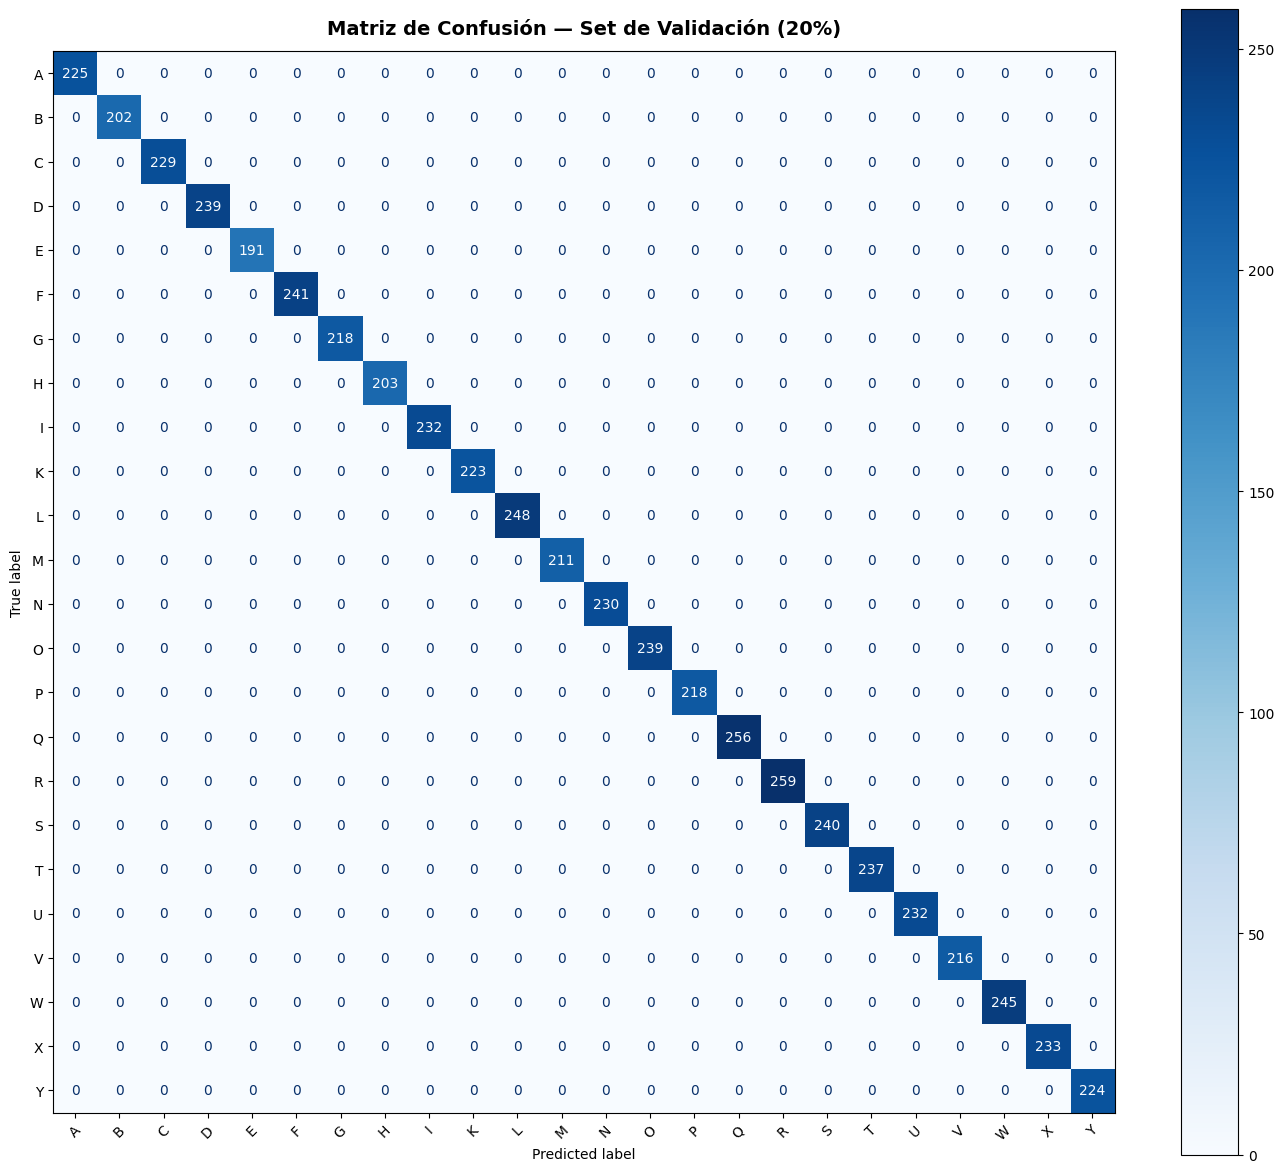

Accuracy global en validación: 1.0000 (100.00%)
Figura guardada como 'confusion_matrix.png'


In [27]:
# Obtener todas las predicciones y etiquetas reales del set de validación
model.to(device)
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in dataloader['val']:
        X_batch = X_batch.to(device)
        preds = torch.argmax(model(X_batch), dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Clases presentes en el set de validación
classes_present = sorted(np.unique(all_labels))
class_names     = [LABEL_MAP[c] for c in classes_present]

cm = confusion_matrix(all_labels, all_preds, labels=classes_present)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(ax=ax, colorbar=True, cmap='Blues',
          xticks_rotation=45)
ax.set_title('Matriz de Confusión — Set de Validación (20%)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

overall_acc = (all_preds == all_labels).mean()
print(f"Accuracy global en validación: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print("Figura guardada como 'confusion_matrix.png'")

---
## 10.  Predicciones Finales Visuales

Mostramos 10 predicciones comparando la imagen de la mano, la letra predicha por la red y el valor real:
- 🟢 **Verde** → predicción correcta
- 🔴 **Rojo** → predicción incorrecta

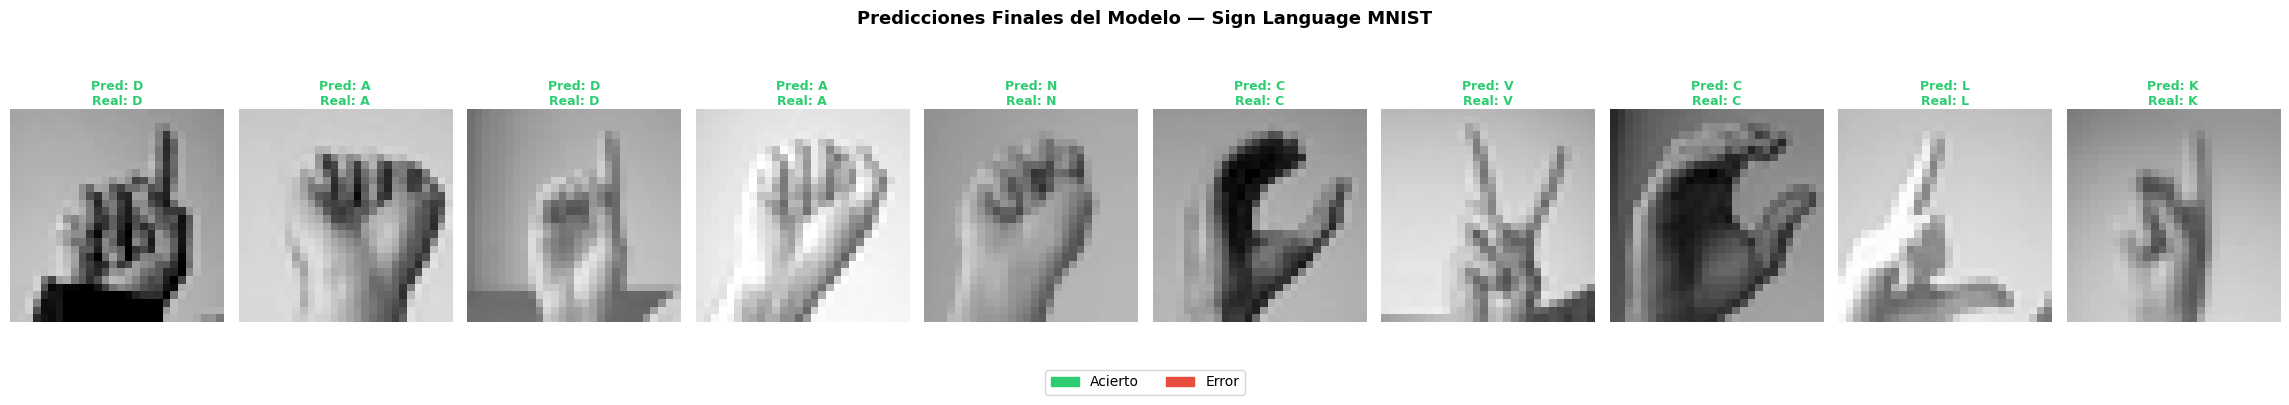

Figura guardada como 'predictions.png'


In [28]:
def show_predictions(model: nn.Module,
                     X: np.ndarray, y: np.ndarray,
                     label_map: dict,
                     n: int = 10,
                     random_state: int = 0) -> None:
    """
    Muestra `n` imágenes del set de validación con su predicción y etiqueta real.
    Verde = acierto, Rojo = fallo.
    """
    rng     = np.random.RandomState(random_state)
    indices = rng.choice(len(X), size=n, replace=False)

    X_sample = torch.tensor(X[indices], dtype=torch.float32).to(device)
    y_sample  = y[indices]

    model.eval()
    with torch.no_grad():
        logits = model(X_sample)
        preds  = torch.argmax(logits, dim=1).cpu().numpy()

    fig, axes = plt.subplots(1, n, figsize=(2.3 * n, 3.5))
    fig.suptitle('Predicciones Finales del Modelo — Sign Language MNIST',
                 fontsize=13, fontweight='bold', y=1.04)

    for ax, i in zip(axes, range(n)):
        img       = X[indices[i]].reshape(28, 28)
        true_lbl  = label_map.get(y_sample[i],  '?')
        pred_lbl  = label_map.get(preds[i],      '?')
        correct   = (preds[i] == y_sample[i])
        color     = '#2ecc71' if correct else '#e74c3c'   # verde / rojo

        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(
            f"Pred: {pred_lbl}\nReal: {true_lbl}",
            fontsize=9, color=color, fontweight='bold', pad=3
        )
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.axis('off')

    # Leyenda
    green_patch = mpatches.Patch(color='#2ecc71', label='Acierto')
    red_patch   = mpatches.Patch(color='#e74c3c', label='Error')
    fig.legend(handles=[green_patch, red_patch],
               loc='lower center', ncol=2,
               bbox_to_anchor=(0.5, -0.08), fontsize=10)

    plt.tight_layout()
    plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Figura guardada como 'predictions.png'")


show_predictions(model, X_val, y_val, LABEL_MAP, n=10)

---
## 11.  Resumen de Archivos Generados

| Archivo | Descripción |
|---|---|
| `checkpoint.pt` | `state_dict` del mejor modelo (mayor val_acc) |
| `sign_language_traced.pt` | Modelo TorchScript vía **tracing** (producción sin Python) |
| `sign_language_scripted.pt` | Modelo TorchScript vía **scripting** (producción sin Python) |
| `train_samples.png` | 10 ejemplos del set de entrenamiento |
| `training_curves.png` | Gráficas de Loss y Accuracy por época |
| `confusion_matrix.png` | Matriz de Confusión sobre el 20% de validación |
| `predictions.png` | 10 predicciones visuales con colores verde/rojo |

In [29]:
import os

files = [
    'checkpoint.pt',
    'sign_language_traced.pt',
    'sign_language_scripted.pt',
    'train_samples.png',
    'training_curves.png',
    'confusion_matrix.png',
    'predictions.png',
]

print("📁 Archivos generados:")
for f in files:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    status = '✅' if os.path.exists(f) else '❌'
    print(f"  {status} {f:<40} {size/1024:>8.1f} KB")

📁 Archivos generados:
  ✅ checkpoint.pt                              2245.2 KB
  ✅ sign_language_traced.pt                    2273.0 KB
  ✅ sign_language_scripted.pt                  2272.9 KB
  ✅ train_samples.png                            43.6 KB
  ✅ training_curves.png                          92.7 KB
  ✅ confusion_matrix.png                         96.1 KB
  ✅ predictions.png                              45.7 KB
